In [1]:
import pandas as pd
import numpy as np

# Importation des données

In [2]:
choix = pd.read_csv("../Data/Traffic_Violations-API_20260324.csv", sep=";")
vetements = pd.read_excel("../Data/fashion_data_2018_2022.xls")

In [3]:
choix = choix.drop(columns=['Time Of Stop', 'Agency', 'SubAgency', 'Description', 'Location', 'Accident', 'Belts', 'Personal Injury', 'Property Damage', 'Fatal', 'Commercial License', 'HAZMAT', 'Alcohol', 'Work Zone', 'Violation Type', 'Charge', 'Article', 'Contributed To Accident', 'Arrest Type', 'Geolocation', 'Latitude', 'Longitude', 'Driver City', 'State', 'DL State', 'Year' ])

avant = len(choix)
temp = choix[choix["VehicleType"] == "02 - Automobile"]
temp = temp.dropna()
apres = len(temp)
perte = avant - apres
pourcentage = (perte / avant) * 100
print(f"Perte de {perte} lignes, soit {pourcentage:.2f} %")

choix = temp

# Convertir en datetime
choix['Date Of Stop'] = pd.to_datetime(choix['Date Of Stop'], format='%m/%d/%Y', errors='coerce')
choix['Year'] = choix['Date Of Stop'].dt.year

basic_colors = ['silver', 'chrome', 'gray', 'white', 'black']
choix['Color'] = choix['Color'].str.lower()
choix['Color Type'] = choix['Color'].apply(lambda x: 'basic' if x in basic_colors else 'not basic')

vetements = vetements[['product_id', 'gender', 'category', 'pattern', 'color', 'age_group', 'sales_count', 'month_of_sale', 'year_of_sale']]

Perte de 243644 lignes, soit 11.58 %


On ne garde que les informations relatives a la voiture et au conducteur.

In [4]:
Meetdeal_mark = ['Citroen', 'Hyundai', 'Seat', 'Skoda', 'Volkswagen', 'CUPRA', 'OPEL', 'Dacia', 'Renault', 'DS', 'VWU',       'AUDI', 'Fiat', 'Peugeot', 'KIA', 'AlfaRomeo', 'Honda', 'Lancia', 'Toyota']

Meetdeal_mark = [x.upper() for x in Meetdeal_mark]

In [14]:
import re
import pandas as pd

# Liste en majuscules + homogénéisée
Meetdeal_mark = [
    'CITROEN','HYUNDAI','SEAT','SKODA','VOLKSWAGEN',
    'CUPRA','OPEL','DACIA','RENAULT','DS',
    'VWU','AUDI','FIAT','PEUGEOT','KIA',
    'ALFAROMEO','HONDA','LANCIA','TOYOTA'
]

def normalize_make(x):
    if pd.isna(x):
        return x
    
    x = x.upper().strip()
    x = re.sub(r'[^A-Z0-9 ]', '', x)

    # Mapping uniquement vers tes marques
    patterns = {
        r'.*\bTOY.*': 'TOYOTA',
        r'.*\bHON.*': 'HONDA',
        r'.*\bHYUN.*|.*\bHYN.*': 'HYUNDAI',
        r'.*\bKIA.*': 'KIA',
        r'.*\bVOLK.*|.*\bVW.*': 'VOLKSWAGEN',
        r'.*\bAUD.*': 'AUDI',
        r'.*\bFIAT.*': 'FIAT',
        r'.*\bPEUG.*': 'PEUGEOT',
        r'.*\bCITR.*': 'CITROEN',
        r'.*\bREN.*': 'RENAULT',
        r'.*\bDAC.*': 'DACIA',
        r'.*\bOPEL.*': 'OPEL',
        r'.*\bSEAT.*': 'SEAT',
        r'.*\bSKO.*': 'SKODA',
        r'.*\bCUPRA.*': 'CUPRA',
        r'.*\bDS.*': 'DS',
        r'.*\bALFA.*': 'ALFAROMEO',
        r'.*\bLANC.*': 'LANCIA'
    }

    for pattern, brand in patterns.items():
        if re.match(pattern, x):
            return brand
    
    return None  # 👈 important : on rejette tout le reste

before = len(choix)
choix["Make"] = choix["Make"].apply(normalize_make)
choix = choix[choix["Make"].isin(Meetdeal_mark)]
after = len(choix)

perte = before - after
pourcentage = perte / before

print(f"Perte de {perte} lignes, soit {pourcentage:.2f} %")

Perte de 0 lignes, soit 0.00 %


In [15]:
print(list(choix["Make"].unique()))

['HONDA', 'TOYOTA', 'VOLKSWAGEN', 'HYUNDAI', 'AUDI', 'KIA', 'ALFAROMEO', 'FIAT', 'PEUGEOT']


In [13]:
Meetdeal_modele = ['C3 aircross', 'C3', 'Ami', 'Tucson', 'Arona', 'Kamiq', 'Taigo', 'Leon', 'C4', 'C5 aircross', 'Vivaro', 'Mokka','Corsa', 'C5 x', 'Kona', 'C4 x', 'Polo', 'Astra', 'Grandland', 'Captur', 'Up!', 'E-up!', 'Crossland', 'Combo', 'Ds 4', 'Ds 7', 'Movano', 'T-roc', 'Id.3', 'Bigster', 'Ibiza', 'I10', 'Bayon', 'Tiguan', 'Octavia', 'Transporter', 'Fabia', 'Karoq', 'Golf', 'T-cross', 'A3', 'Elroq', '600', '208', 'Frontera', 'Niro', 'Stonic', 'Ceed', 'Inster', 'Sportage', 'Picanto', 'Tonale', 'Jazz', 'Q4 e-tron', 'Ateca', 'Id.4', 'Formentor', 'Tayron', 'Born', 'Ev3', '600e', 'Junior', 'Topolino', 'Ds 3', '500e', 'Hr-v', 'Ev6', '408', 'Ypsilon', 'Kodiaq', 'Q5', 'Q2', 'A1', 'I20', 'Terramar', 'Tavascan', 'Q3', 'Enyaq', 'Yaris', 'A6']

Meetdeal_modele = [x.upper() for x in Meetdeal_modele]

In [16]:
def normalize_model(x):
    if pd.isna(x):
        return x

    x = str(x).upper().strip()
    x = re.sub(r'[^A-Z0-9 ]', '', x)

    # Mapping des motifs vers les modèles standardisés
    patterns = {
        # Modèles Citroën
        r'.*\bC3.*AIRCROSS.*': 'C3 AIRCROSS',
        r'.*\bC3\b.*': 'C3',
        r'.*\bC4.*AIRCROSS.*': 'C4 AIRCROSS',
        r'.*\bC4.*X.*': 'C4 X',
        r'.*\bC4\b.*': 'C4',
        r'.*\bC5.*AIRCROSS.*': 'C5 AIRCROSS',
        r'.*\bC5.*X.*': 'C5 X',
        # Modèles Hyundai
        r'.*\bTUCSON.*': 'TUCSON',
        r'.*\bKONA.*': 'KONA',
        r'.*\bI10.*': 'I10',
        r'.*\bI20.*': 'I20',
        # Modèles Seat
        r'.*\bARONA.*': 'ARONA',
        r'.*\bLEON.*': 'LEON',
        r'.*\bIBIZA.*': 'IBIZA',
        # Modèles Skoda
        r'.*\bKAMIQ.*': 'KAMIQ',
        r'.*\bOCTAVIA.*': 'OCTAVIA',
        r'.*\bKAROQ.*': 'KAROQ',
        # Modèles Volkswagen
        r'.*\bPOLO.*': 'POLO',
        r'.*\bGOLF.*': 'GOLF',
        r'.*\bT\-?ROC.*': 'T-ROC',
        r'.*\bID\.?3.*': 'ID.3',
        r'.*\bID\.?4.*': 'ID.4',
        r'.*\bUP.*': 'UP!',
        r'.*\bE\-?UP.*': 'E-UP!',
        # Modèles Opel
        r'.*\bCORSA.*': 'CORSA',
        r'.*\bASTRA.*': 'ASTRA',
        r'.*\bGRANDLAND.*': 'GRANDLAND',
        r'.*\bCROSSLAND.*': 'CROSSLAND',
        r'.*\bCOMBO.*': 'COMBO',
        r'.*\bVIVARO.*': 'VIVARO',
        r'.*\bMOVANO.*': 'MOVANO',
        # Modèles Dacia
        r'.*\bDS\b.*3.*': 'DS 3',
        r'.*\bDS\b.*4.*': 'DS 4',
        r'.*\bDS\b.*7.*': 'DS 7',
        # Modèles Renault
        r'.*\bCAPTUR.*': 'CAPTUR',
        # Modèles Toyota
        r'.*\bYARIS.*': 'YARIS',
        r'.*\bCOROLLA.*': 'COROLLA',  # À adapter selon ta liste
        # Modèles Kia
        r'.*\bNIRO.*': 'NIRO',
        r'.*\bSTONIC.*': 'STONIC',
        r'.*\bCEED.*': 'CEED',
        r'.*\bSPORTAGE.*': 'SPORTAGE',
        r'.*\bPICANTO.*': 'PICANTO',
        # Modèles Honda
        r'.*\bJAZZ.*': 'JAZZ',
        r'.*\bHR\-?V.*': 'HR-V',
        # Modèles Audi
        r'.*\bA3.*': 'A3',
        r'.*\bA6.*': 'A6',
        r'.*\bQ2.*': 'Q2',
        r'.*\bQ3.*': 'Q3',
        r'.*\bQ5.*': 'Q5',
        r'.*\bQ4.*E\-?TRON.*': 'Q4 E-TRON',
        # Modèles Peugeot
        r'.*\b208.*': '208',
        r'.*\b408.*': '408',
        # Modèles Fiat
        r'.*\b500.*E.*': '500E',
        r'.*\bYPSILON.*': 'YPSILON',
        # Modèles Cupra
        r'.*\bATECA.*': 'ATECA',
        r'.*\bFORMENTOR.*': 'FORMENTOR',
        # Modèles Alfa Romeo
        r'.*\bTONALE.*': 'TONALE',
        # Modèles Lancia
        r'.*\bYPSILON.*': 'YPSILON',
        # Modèles DS
        r'.*\bDS\b.*3.*': 'DS 3',
        r'.*\bDS\b.*4.*': 'DS 4',
        r'.*\bDS\b.*7.*': 'DS 7',
        # Modèles divers
        r'.*\bTERRAMAR.*': 'TERRAMAR',
        r'.*\bTAVASCAN.*': 'TAVASCAN',
        r'.*\bENYAQ.*': 'ENYAQ',
        r'.*\bEV6.*': 'EV6',
        r'.*\bEV3.*': 'EV3',
        r'.*\b600E.*': '600E',
        r'.*\bJUNIOR.*': 'JUNIOR',
        r'.*\bTOPOLINO.*': 'TOPOLINO',
    }

    for pattern, model in patterns.items():
        if re.match(pattern, x):
            return model

    return None

# Application
before = len(choix)
choix["Model"] = choix["Model"].apply(normalize_model)
choix = choix[choix["Model"].isin(Meetdeal_modele)]
after = len(choix)

perte = before - after
pourcentage = perte / before

print(f"Perte de {perte} lignes, soit {pourcentage:.2%} du dataset initial.")

Perte de 802223 lignes, soit 98.07% du dataset initial.


In [17]:
print(list(choix["Model"].unique()))

['HR-V', 'Q5', 'YARIS', 'A3', 'ID.4', 'SPORTAGE', 'TUCSON', 'GOLF', 'NIRO', 'KONA', 'Q3', 'A6', 'EV6', 'POLO', 'Q4 E-TRON', 'Q2', 'UP!']


In [ ]:
choix.head()

,Date Of Stop,Commercial Vehicle,VehicleType,Make,Model,Color,Race,Gender,Driver State,Year,Color Type
45,2026-03-23,No,02 - Automobile,HONDA,HR-V,gray,BLACK,M,MD,2026,basic
88,2026-03-22,No,02 - Automobile,AUDI,Q5,"blue, light",BLACK,F,MD,2026,not basic
89,2026-03-22,No,02 - Automobile,AUDI,Q5,"blue, light",BLACK,F,MD,2026,not basic
543,2026-03-21,No,02 - Automobile,TOYOTA,YARIS,silver,HISPANIC,F,MD,2026,basic
551,2026-03-21,No,02 - Automobile,AUDI,A3,black,BLACK,F,MD,2026,basic


In [19]:
vetements.head()

,product_id,gender,category,pattern,color,age_group,sales_count,month_of_sale,year_of_sale
0,1001,Male,Shirt,Geometric,White,25-35,75,1,2018
1,1002,Male,Jacket,Polka Dots,Beige,18-24,296,1,2018
2,1003,Female,Dress,Geometric,Brown,18-24,50,1,2018
3,1004,Male,Shorts,Plain,White,25-35,435,1,2018
4,1005,Male,Shirt,Plain,Beige,35-45,79,1,2018


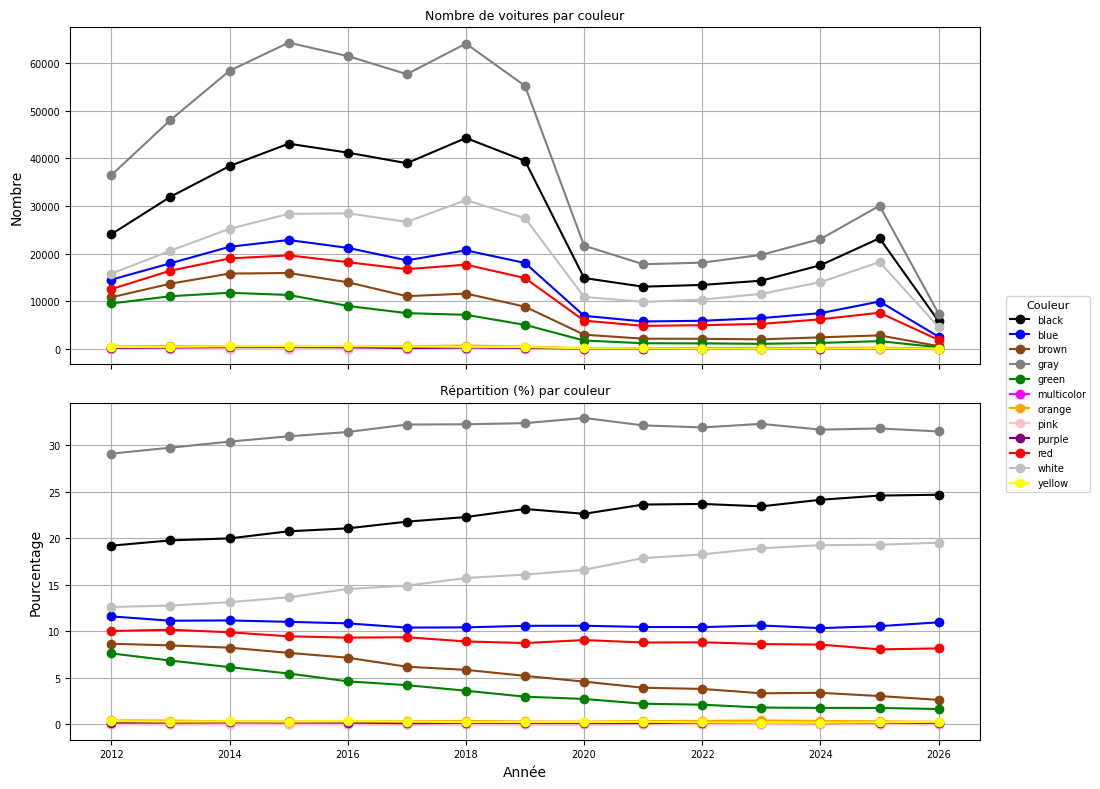

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Préparation des données
# -----------------------------

color_map = {
    'blue': ['blue', 'blue, light', 'blue, dark'],
    'green': ['green', 'green, lgt', 'green, dk'],
    'red': ['red', 'maroon'],
    'brown': ['brown', 'tan', 'cream', 'gold', 'bronze', 'copper', 'beige'],
    'white': ['white'],
    'black': ['black'],
    'orange': ['orange'],
    'yellow': ['yellow'],
    'pink': ['pink'],
    'purple': ['purple'],
    'multicolor': ['multicolor', 'camouflage'],
    'gray': ['silver', 'chrome', 'gray']
}

def general_color(c):
    for gen, shades in color_map.items():
        if c in shades:
            return gen
    return 'other'

choix['Color_general'] = choix['Color'].apply(general_color)

counts = choix.groupby(['Year', 'Color_general']).size().unstack(fill_value=0)
counts_percent = counts.div(counts.sum(axis=1), axis=0) * 100

palette = {
    'blue': 'blue',
    'green': 'green',
    'red': 'red',
    'brown': 'saddlebrown',
    'white': 'silver',
    'black': 'black',
    'orange': 'orange',
    'yellow': 'yellow',
    'pink': 'pink',
    'purple': 'purple',
    'multicolor': 'magenta',
    'gray': 'gray',
    'other': 'cyan'
}

# -----------------------------
# Subplots
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

lines = []
labels = []

# ---- Graphique 1 ----
for color in counts.columns:
    line, = axes[0].plot(
        counts.index,
        counts[color],
        marker='o',
        color=palette.get(color, 'gray'),
        label=color
    )
    lines.append(line)
    labels.append(color)

axes[0].set_title("Nombre de voitures par couleur")
axes[0].set_ylabel("Nombre")
axes[0].grid(True)

# ---- Graphique 2 ----
for color in counts_percent.columns:
    axes[1].plot(
        counts_percent.index,
        counts_percent[color],
        marker='o',
        color=palette.get(color, 'gray')
    )

axes[1].set_title("Répartition (%) par couleur")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Pourcentage")
axes[1].grid(True)

# -----------------------------
# Légende unique
# -----------------------------
fig.legend(
    lines, labels,
    title="Couleur",
    loc='center right',
    bbox_to_anchor=(1.1, 0.5),
    fontsize=7,
    title_fontsize=8
)

# Ajustements taille texte
for ax in axes:
    ax.tick_params(labelsize=7)
    ax.title.set_size(9)

plt.tight_layout()
plt.show()

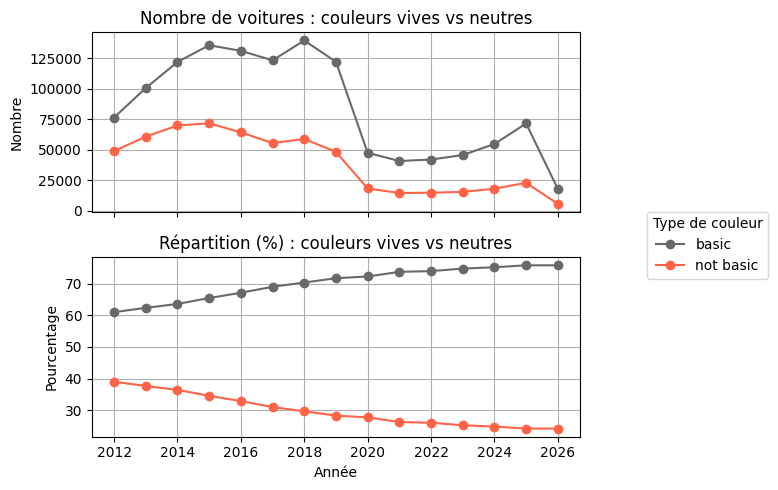

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 2️⃣ Agrégation
# -----------------------------
counts = choix.groupby(['Year', 'Color Type']).size().unstack(fill_value=0)
counts_percent = counts.div(counts.sum(axis=1), axis=0) * 100

# -----------------------------
# 3️⃣ Palette
# -----------------------------
palette = {
    'not basic': 'tomato',
    'basic': 'dimgray',
    'other': 'cyan'
}

# -----------------------------
# 4️⃣ Subplots
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(6, 5), sharex=True)

lines = []
labels = []

# ---- Graphique 1 ----
for t in counts.columns:
    line, = axes[0].plot(
        counts.index,
        counts[t],
        marker='o',
        color=palette.get(t, 'black'),
        label=t
    )
    lines.append(line)
    labels.append(t)

axes[0].set_title("Nombre de voitures : couleurs vives vs neutres")
axes[0].set_ylabel("Nombre")
axes[0].grid(True)

# ---- Graphique 2 ----
for t in counts_percent.columns:
    axes[1].plot(
        counts_percent.index,
        counts_percent[t],
        marker='o',
        color=palette.get(t, 'black')
    )

axes[1].set_title("Répartition (%) : couleurs vives vs neutres")
axes[1].set_xlabel("Année")
axes[1].set_ylabel("Pourcentage")
axes[1].grid(True)

# -----------------------------
# 5️⃣ Légende unique
# -----------------------------
fig.legend(lines, labels, title="Type de couleur",
           loc='center right', bbox_to_anchor=(1.3, 0.5))

plt.tight_layout()
plt.show()

La baisse des accidents de la route aux États-Unis en 2020 est principalement due à la pandémie de COVID-19, qui a fortement réduit les déplacements (confinements, télétravail). Moins de voitures sur les routes = moins d’accidents.

# Prédiction 

## Info interne

### Couleur précise

In [ ]:
# Features (X) et target (y)
X = choix[["Commercial Vehicle", "VehicleType", "Year", "Make", "Model", "Race", "Gender", "Driver State"]]
y = choix["Color_general"]

In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = X.columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier())
])

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))

### Type de couleur

In [ ]:
# Features (X) et target (y)
X = choix[["Commercial Vehicle", "VehicleType", "Year", "Make", "Model", "Race", "Gender", "Driver State"
]]
y = choix["Color Type"]

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = X.columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy :", accuracy_score(y_test, y_pred))

## Vetement 

In [7]:
choix_h = choix[choix['Gender'] == 'M']
vetement_h = vetements[vetements['gender'] == 'Male']

In [9]:
dist_voiture = choix_h['Color'].value_counts(normalize=True)
dist_vetement = vetement_h['color'].value_counts(normalize=True)

Couleurs communes : Index(['black', 'white', 'red', 'green', 'beige', 'brown', 'orange', 'yellow',
       'pink'],
      dtype='str')


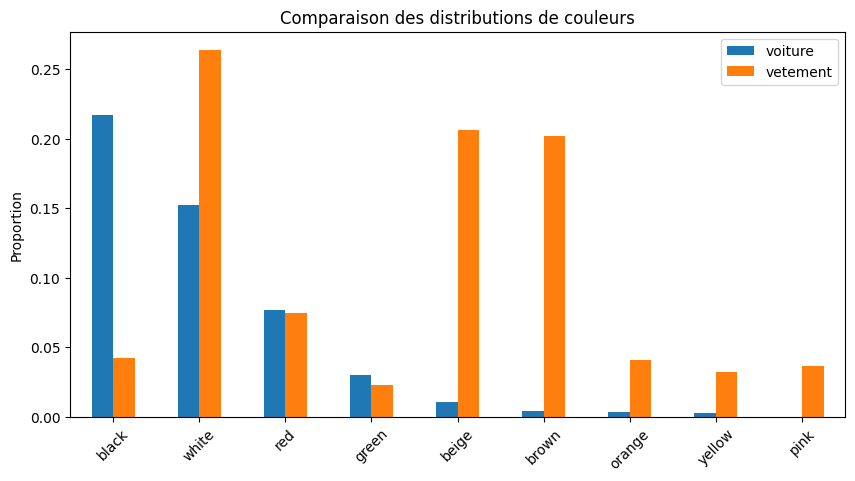

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# distributions
dist_voiture = choix['Color'].str.lower().value_counts(normalize=True)
dist_vetement = vetements['color'].str.lower().value_counts(normalize=True)

# couleurs communes
common = dist_voiture.index.intersection(dist_vetement.index)

print("Couleurs communes :", common)

df = pd.DataFrame({
    'voiture': dist_voiture.loc[common],
    'vetement': dist_vetement.loc[common]
})

df.plot(kind='bar', figsize=(10,5))
plt.title("Comparaison des distributions de couleurs")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()